Este script es del curso de Forex (trading algoritmico)
   Implementa una estrategia de cruce de dos medias móviles simples (SMA:
   SMA 50 : media móvil corta
   SMA 200 : media móvil larga
   La estrategia consiste en:
   asumir largo (+1) cuando SMA 50 cruce hacia arriba de SMA 200
   asumir corto (-1) cuando SMA 50 cruce hacia abajo de de SMA 200
   Calcular rendimientos y comparar con B/H 


In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')


# lectura de los datos
data = pd.read_csv("datos_historia.csv", parse_dates=["Date"], index_col = "Date")
data.head()

,price
Date,
2023-01-01 00:04:59.999,10.00
2023-01-01 00:09:59.999,9.96
2023-01-01 00:14:59.999,9.95
2023-01-01 00:19:59.999,9.97
2023-01-01 00:24:59.999,9.98


In [25]:
# períodos de las medias móviles

sma_s = 50
sma_l = 200


In [26]:
# calcular las dos medias y agregarlas como columnas (SMA_S, SMA_L) al dataframe data
data['SMA_S'] = data.price.rolling(sma_s).mean()
data['SMA_L'] = data.price.rolling(sma_l).mean()
data

,price,SMA_S,SMA_L
Date,,,
2023-01-01 00:04:59.999,10.00,NaN,NaN
2023-01-01 00:09:59.999,9.96,NaN,NaN
2023-01-01 00:14:59.999,9.95,NaN,NaN
2023-01-01 00:19:59.999,9.97,NaN,NaN
2023-01-01 00:24:59.999,9.98,NaN,NaN
...,...,...,...
2023-12-30 23:44:59.999,101.83,102.7578,102.89140
2023-12-30 23:49:59.999,101.96,102.7224,102.87920
2023-12-30 23:54:59.999,101.66,102.6826,102.86535


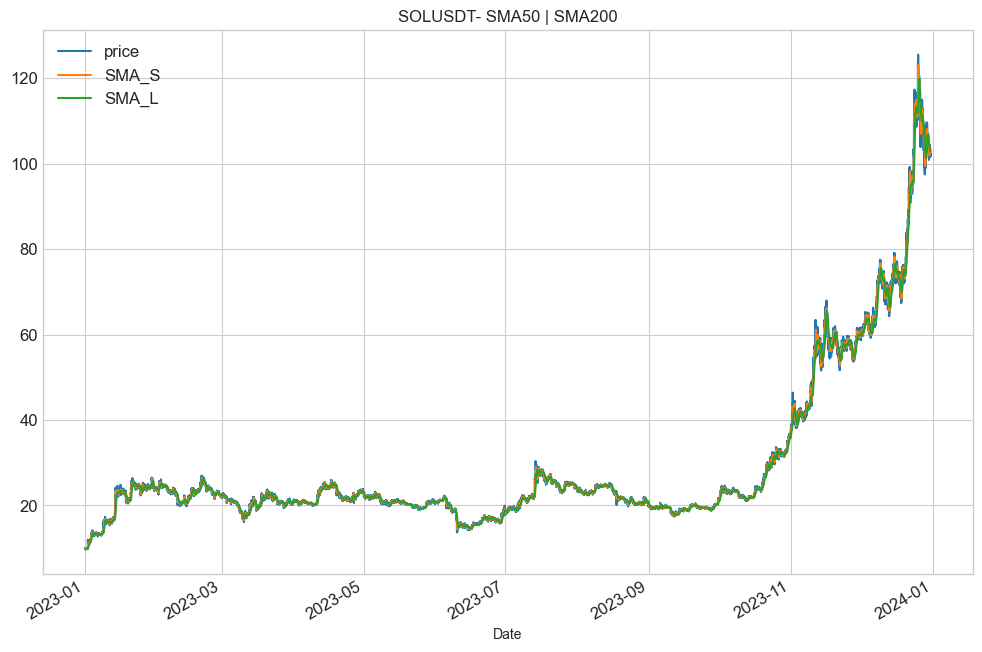

In [27]:
# graficar los datos
data.plot(figsize = (12, 8), title = "SOLUSDT- SMA{} | SMA{}".format(sma_s, sma_l),fontsize = 12)
plt.legend(fontsize = 12)
plt.show()

In [28]:
# crea una nueva columna (position) para luego calcular los rendimientos de
# la estrategia a partir de esta. Esta columna define la estratagie de cruces.
data['position'] = np.where(data['SMA_S'] > data['SMA_L'], 1, -1)
data

,price,SMA_S,SMA_L,position
Date,,,,
2023-01-01 00:04:59.999,10.00,NaN,NaN,-1
2023-01-01 00:09:59.999,9.96,NaN,NaN,-1
2023-01-01 00:14:59.999,9.95,NaN,NaN,-1
2023-01-01 00:19:59.999,9.97,NaN,NaN,-1
2023-01-01 00:24:59.999,9.98,NaN,NaN,-1
...,...,...,...,...
2023-12-30 23:44:59.999,101.83,102.7578,102.89140,-1
2023-12-30 23:49:59.999,101.96,102.7224,102.87920,-1
2023-12-30 23:54:59.999,101.66,102.6826,102.86535,-1


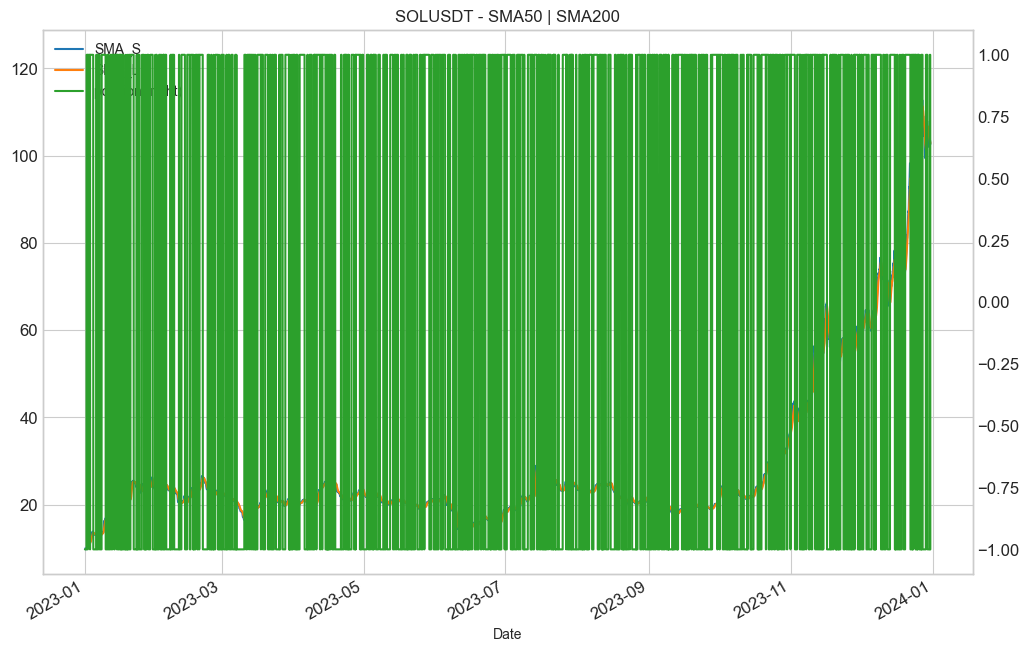

In [29]:
# graficar las SMAs con la señal biestable de compra-venta
data.loc[:, ['SMA_S', 'SMA_L', 'position']].plot(figsize=(12, 8), \
        fontsize = 12, secondary_y = 'position', \
        title= "SOLUSDT - SMA{} | SMA{}".format(sma_s, sma_l))
plt.show()


In [30]:
# graficar solo un mes para realizar zoom a la gráfica
"""
data.loc['2023-01-01':'2023-01-31',['SMA_S', 'SMA_L', 'position']].plot(figsize=(12, 8), \
        fontsize = 12, secondary_y = 'position', \
        title= "SOLUSDT - SMA{} | SMA{}".format(sma_s, sma_l))
plt.show()
"""
datos_mes = data.loc['2023-10']
datos_mes



,price,SMA_S,SMA_L,position
Date,,,,
2023-10-01 00:04:59.999,21.30,21.3634,20.98975,1
2023-10-01 00:09:59.999,21.32,21.3616,20.99490,1
2023-10-01 00:14:59.999,21.39,21.3608,21.00020,1
2023-10-01 00:19:59.999,21.37,21.3602,21.00540,1
2023-10-01 00:24:59.999,21.33,21.3598,21.01045,1
...,...,...,...,...
2023-10-31 23:39:59.999,38.25,37.2224,36.47170,1
2023-10-31 23:44:59.999,38.37,37.2640,36.48385,1
2023-10-31 23:49:59.999,38.47,37.3084,36.49630,1


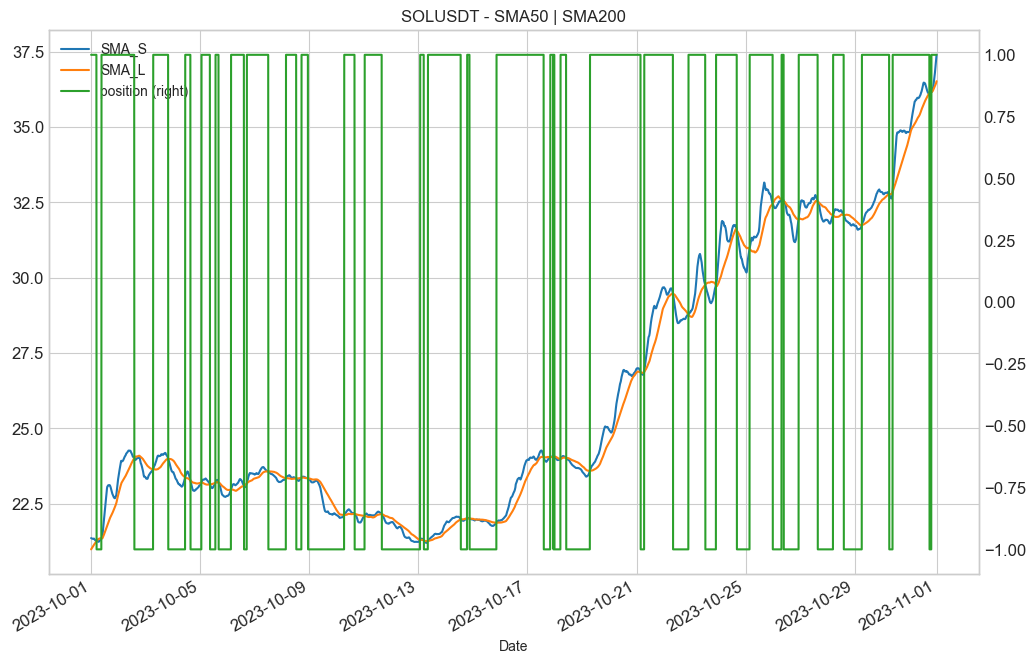

In [31]:
datos_mes.loc[:,['SMA_S', 'SMA_L', 'position']].plot(figsize=(12, 8), \
        fontsize = 12, secondary_y = 'position', \
        title= "SOLUSDT - SMA{} | SMA{}".format(sma_s, sma_l))
plt.show()

calcular los rendimientos diarios con el logaritmo natural
esta operación consiste en calcular el rendimiento como el 
cuociente entre el precio del dia de hoy entre el precio
del dia de ayer y luego sacar el ln del resultado
esto corresponde a la estrategia B/H, es decir, compré
al inicio del período de los datos de precios históricos
y mantuve la inversión hasta el último día del período
considerado

In [32]:


data["return"] = np.log(data.price.div(data.price.shift(1)))


# a continuación se calculan los rendimientos de esta estrategia
# de cruce de medias móviles mediante el producto de la posición
# del día anterior por el rendimiento del día actual 
data["strategy"] = data.position.shift(1) * data["return"]

data.dropna(inplace=True)



In [33]:
data[["return", "strategy"]].sum() #realización absoluta



return      2.334659
strategy    1.335807
dtype: float64

In [34]:
data[["return", "strategy"]].sum().apply(np.exp)

return      10.325933
strategy     3.803064
dtype: float64

In [35]:
data[["return", "strategy"]].mean() * 252 # realización anualizada



return      0.005624
strategy    0.003218
dtype: float64

In [36]:
data[["return", "strategy"]].std() * np.sqrt(252) # riesgo anualizado




return      0.050226
strategy    0.050226
dtype: float64

In [37]:
data["creturn"] = data["return"].cumsum().apply(np.exp)
data["cstrategy"] = data["strategy"].cumsum().apply(np.exp)



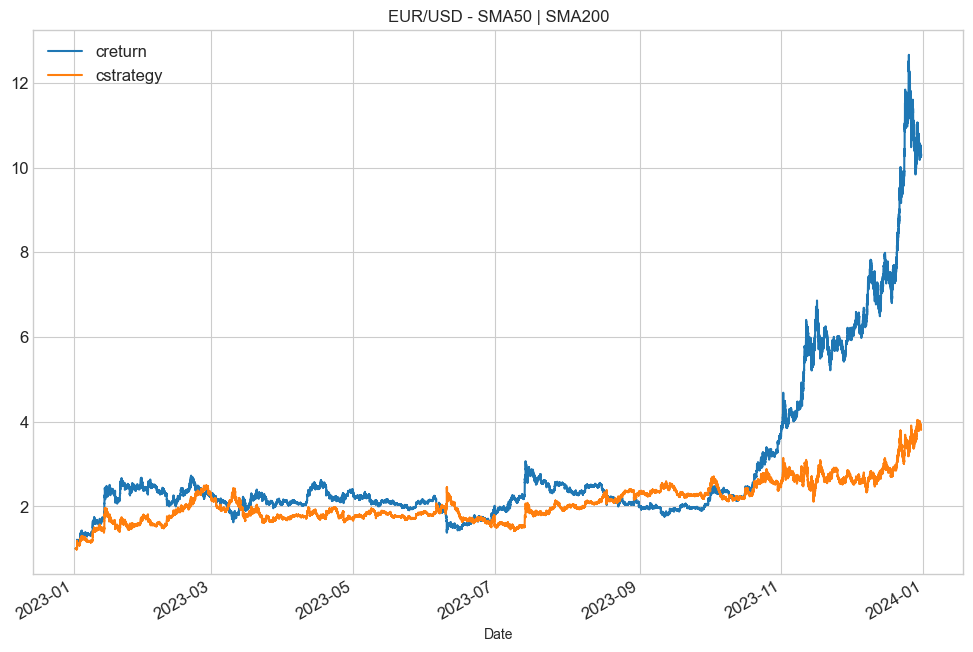

In [38]:
data[["creturn", "cstrategy"]].plot(figsize = (12, 8), title = "EUR/USD - SMA{} | SMA{}".format(50, 200), fontsize = 12)
plt.legend(fontsize = 12)
plt.show()




In [39]:
outperf = data.cstrategy.iloc[-1] - data.creturn.iloc[-1]
outperf


np.float64(-6.522869613729077)